In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [2]:
data = pd.read_csv("../data/House_Price_Data.csv")
data

,bhk,propertytype,location,sqft,pricepersqft,totalprice
0,3,Flat,Ahmedabad,1346,6233,15700000
1,4,Flat,Ahmedabad,1872,4873,17500000
2,4,Flat,Ahmedabad,1650,6733,20200000
3,5,Flat,Ahmedabad,10201,8499,86700000
4,3,Flat,Ahmedabad,968,5944,10400000
...,...,...,...,...,...,...
14114,2,House,Warangal,1000,9459,9000000
14115,2,House,Warangal,1710,12849,14000000
14116,2,House,Warangal,800,5575,2600000
14117,2,House,Warangal,1591,4200,15000000


In [3]:
X = data.sqft
y = data.totalprice

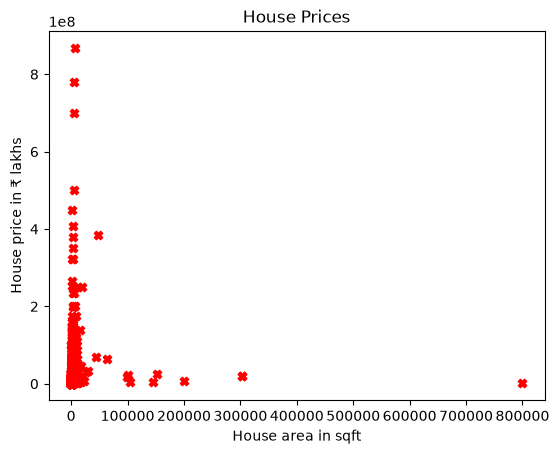

In [4]:
plt.scatter(X, y, marker="X", c="r")
plt.title("House Prices")
plt.xlabel("House area in sqft")
plt.ylabel("House price in ₹ lakhs")
plt.show()

In [5]:
mask = X < 10000
X = X[mask]
y = y[mask]

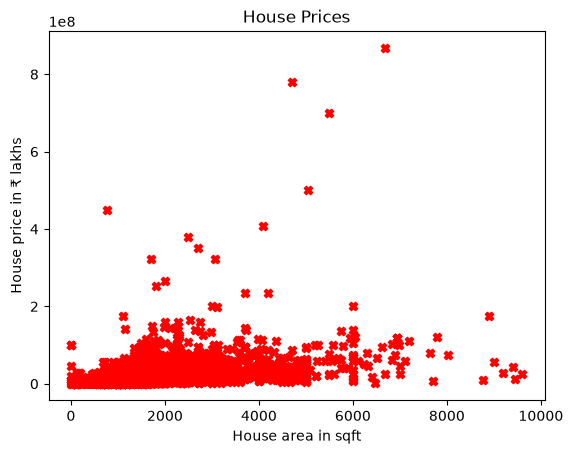

In [6]:
plt.scatter(X, y, marker="X", c="r")
plt.title("House Prices")
plt.xlabel("House area in sqft")
plt.ylabel("House price in ₹ lakhs")
plt.show()

In [7]:
y = y/100000

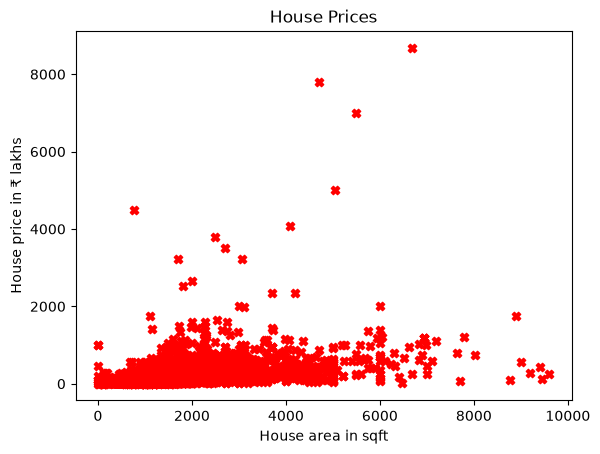

In [8]:
plt.scatter(X, y, marker="X", c="r")
plt.title("House Prices")
plt.xlabel("House area in sqft")
plt.ylabel("House price in ₹ lakhs")
plt.show()

In [9]:
mask = X < 4500

X = X[mask]
y = y[mask]

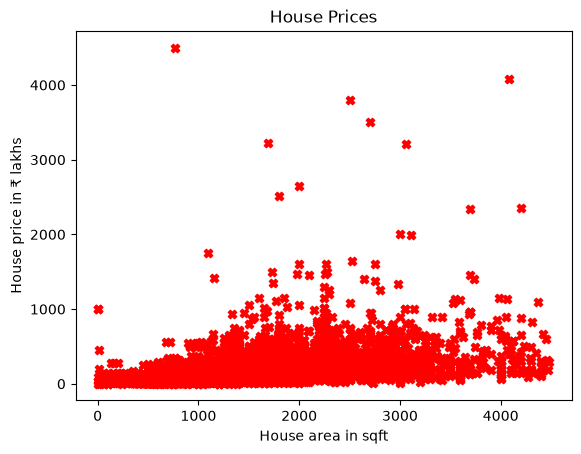

In [10]:
plt.scatter(X, y, marker="X", c="r")
plt.title("House Prices")
plt.xlabel("House area in sqft")
plt.ylabel("House price in ₹ lakhs")
plt.show()

In [11]:
X = X.to_numpy()
y = y.to_numpy()

In [12]:
def compute_fwb(x, w, b):
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w*x[i] + b

    return f_wb

In [13]:
def Squared_error_Cost(x, y, w, b):
    cost = 0
    m = y.shape[0]
    for i in range(m):
        fwb = w*x[i]+b
        cost += (fwb - y[i])**2
    return cost/(2*m)

In [14]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        fwb = w*x[i] + b

        dj_dw_i = (fwb - y[i]) * x[i]
        dj_db_i = (fwb - y[i])

        dj_dw += dj_dw_i
        dj_db += dj_db_i

    dj_dw = dj_dw/m
    dj_db = dj_db/m

    return dj_dw, dj_db

In [15]:
x_scaled  = (X-X.mean())/X.std()

In [16]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iter, cost_funtion, gradient_function):
    j_history = []
    p_history = []

    b = b_in
    w = w_in

    for i in range(num_iter):
        dj_dw, dj_db = gradient_function(x, y, w, b)

        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        if i < 100000:
            j_history.append(cost_funtion(x, y, w, b))
            p_history.append([w,b])
        if i% math.ceil(num_iter/10) == 0:
            print(f"Iteration {i:4}: Cost {j_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")
    return w, b, j_history, p_history

In [17]:
w_init = 0
b_init = 0
iterations = 10000
tmp_alpha = 1.0e-2
w_final, b_final, J_hist, p_hist = gradient_descent(x_scaled ,y, w_init, b_init, tmp_alpha, iterations, Squared_error_Cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 2.00e+04  dj_dw: -7.477e+01, dj_db: -1.210e+02   w:  7.477e-01, b: 1.21026e+00
Iteration 1000: Cost 1.01e+04  dj_dw: -3.228e-03, dj_db: -5.225e-03   w:  7.477e+01, b: 1.21021e+02
Iteration 2000: Cost 1.01e+04  dj_dw: -1.394e-07, dj_db: -2.256e-07   w:  7.477e+01, b: 1.21026e+02
Iteration 3000: Cost 1.01e+04  dj_dw: -6.035e-12, dj_db: -9.761e-12   w:  7.477e+01, b: 1.21026e+02
Iteration 4000: Cost 1.01e+04  dj_dw: -6.771e-13, dj_db: -6.954e-13   w:  7.477e+01, b: 1.21026e+02
Iteration 5000: Cost 1.01e+04  dj_dw: -6.771e-13, dj_db: -6.954e-13   w:  7.477e+01, b: 1.21026e+02
Iteration 6000: Cost 1.01e+04  dj_dw: -6.771e-13, dj_db: -6.954e-13   w:  7.477e+01, b: 1.21026e+02
Iteration 7000: Cost 1.01e+04  dj_dw: -6.771e-13, dj_db: -6.954e-13   w:  7.477e+01, b: 1.21026e+02
Iteration 8000: Cost 1.01e+04  dj_dw: -6.771e-13, dj_db: -6.954e-13   w:  7.477e+01, b: 1.21026e+02
Iteration 9000: Cost 1.01e+04  dj_dw: -6.771e-13, dj_db: -6.954e-13   w:  7.477e+01, b: 1.21026e+02
